# Target Network Comparison

This notebook compares two approaches to computing Q-learning bootstrap targets:

| Version | Target source | Update rule |
|---------|--------------|-------------|
| **Original** | Same network that is being trained | — (no separation) |
| **Soft Polyak** | Exponential moving average of online weights | `θ_target ← (1−τ)θ_target + τ θ_online` every replay |

All comparisons run on a synthetic Q-learning task — no SUMO needed.

**Run cells top-to-bottom.**

## 1. Setup

In [1]:
import copy

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(0)
np.random.seed(0)

Device: cuda


## 2. Synthetic Q-Learning Environment

We create a small tabular MDP (8 states, 4 actions) with a known optimal Q-table,
then train a tiny MLP to approximate it via Q-learning updates.
This isolates the effect of the target strategy from SUMO noise.

In [2]:
N_STATES  = 8
N_ACTIONS = 4
GAMMA     = 0.75

rng = np.random.default_rng(42)

R = rng.uniform(-1, 0, (N_STATES, N_ACTIONS)).astype(np.float32)
T = rng.integers(0, N_STATES, (N_STATES, N_ACTIONS))

Q_star = np.zeros((N_STATES, N_ACTIONS), dtype=np.float32)
for _ in range(2000):
    Q_new = R + GAMMA * Q_star[T].max(axis=-1)
    Q_star = Q_new

print("Optimal Q-table (Q*):")
print(np.round(Q_star, 3))
print(f"\nQ* range: [{Q_star.min():.3f}, {Q_star.max():.3f}]")

Optimal Q-table (Q*):
[[-0.561 -0.867 -0.396 -0.609]
 [-1.202 -0.36  -0.89  -0.484]
 [-1.207 -0.819 -0.874 -0.408]
 [-0.662 -0.447 -0.888 -1.017]
 [-0.7   -1.271 -0.442 -1.02 ]
 [-0.486 -0.89  -0.326 -0.413]
 [-0.873 -1.457 -0.868 -1.608]
 [-1.497 -0.652 -0.509 -0.339]]

Q* range: [-1.608, -0.326]


## 3. Network and Training Utilities

In [3]:
class QNet(nn.Module):
    def __init__(self, n_states, n_actions, width=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, width), nn.ReLU(),
            nn.Linear(width, width),   nn.ReLU(),
            nn.Linear(width, n_actions),
        )
    def forward(self, x):
        return self.net(x)


def one_hot(states, n_states):
    t = torch.zeros(len(states), n_states, device=DEVICE)
    t[range(len(states)), states] = 1.0
    return t


def sample_batch(batch_size=64):
    s  = rng.integers(0, N_STATES, batch_size)
    a  = rng.integers(0, N_ACTIONS, batch_size)
    r  = R[s, a]
    s2 = T[s, a]
    return s, a, r, s2


def q_error(net):
    net.eval()
    with torch.no_grad():
        all_states = one_hot(list(range(N_STATES)), N_STATES)
        q_pred = net(all_states).cpu().numpy()
    return float(np.abs(q_pred - Q_star).mean())


print("Utilities defined.")

Utilities defined.


## 4. Training Loop — Two Strategies

Each strategy runs for the same number of steps from the same random initialisation.

In [4]:
N_STEPS   = 3000
LR        = 1e-3
BATCH     = 64
TAU       = 0.005
LOG_EVERY = 10


def run_training(mode: str):
    """
    mode: 'no_target'  — single network, targets from online network (original)
          'polyak'     — soft Polyak update every step (current)
    """
    torch.manual_seed(99)

    online = QNet(N_STATES, N_ACTIONS).to(DEVICE)
    target = copy.deepcopy(online)
    for p in target.parameters():
        p.requires_grad = False

    optimizer = optim.Adam(online.parameters(), lr=LR)
    loss_fn   = nn.HuberLoss()

    losses, errors, target_divergence = [], [], []

    for step in range(N_STEPS):
        s, a, r, s2 = sample_batch(BATCH)

        s_t  = one_hot(s,  N_STATES)
        s2_t = one_hot(s2, N_STATES)
        r_t  = torch.tensor(r, device=DEVICE)
        a_t  = torch.tensor(a, device=DEVICE)

        online.train()
        q_online = online(s_t)

        with torch.no_grad():
            if mode == "no_target":
                q_next = online(s2_t).max(dim=1).values
            else:
                q_next = target(s2_t).max(dim=1).values

        td_target = r_t + GAMMA * q_next
        q_pred    = q_online[range(BATCH), a_t]

        loss = loss_fn(q_pred, td_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if mode == "polyak":
            for p_on, p_tgt in zip(online.parameters(), target.parameters()):
                p_tgt.data.mul_(1.0 - TAU).add_(TAU * p_on.data)

        if step % LOG_EVERY == 0:
            losses.append(float(loss.item()))
            errors.append(q_error(online))
            with torch.no_grad():
                div = sum(
                    (p_on - p_tgt).abs().mean().item()
                    for p_on, p_tgt in zip(online.parameters(), target.parameters())
                )
            target_divergence.append(div)

    return np.array(losses), np.array(errors), np.array(target_divergence)


print("Running no_target ...")
loss_nt, err_nt, div_nt = run_training("no_target")

print("Running polyak    ...")
loss_pk, err_pk, div_pk = run_training("polyak")

print("Done.")

Running no_target ...
Running polyak    ...
Done.


## 5. Results — Side-by-Side Comparison

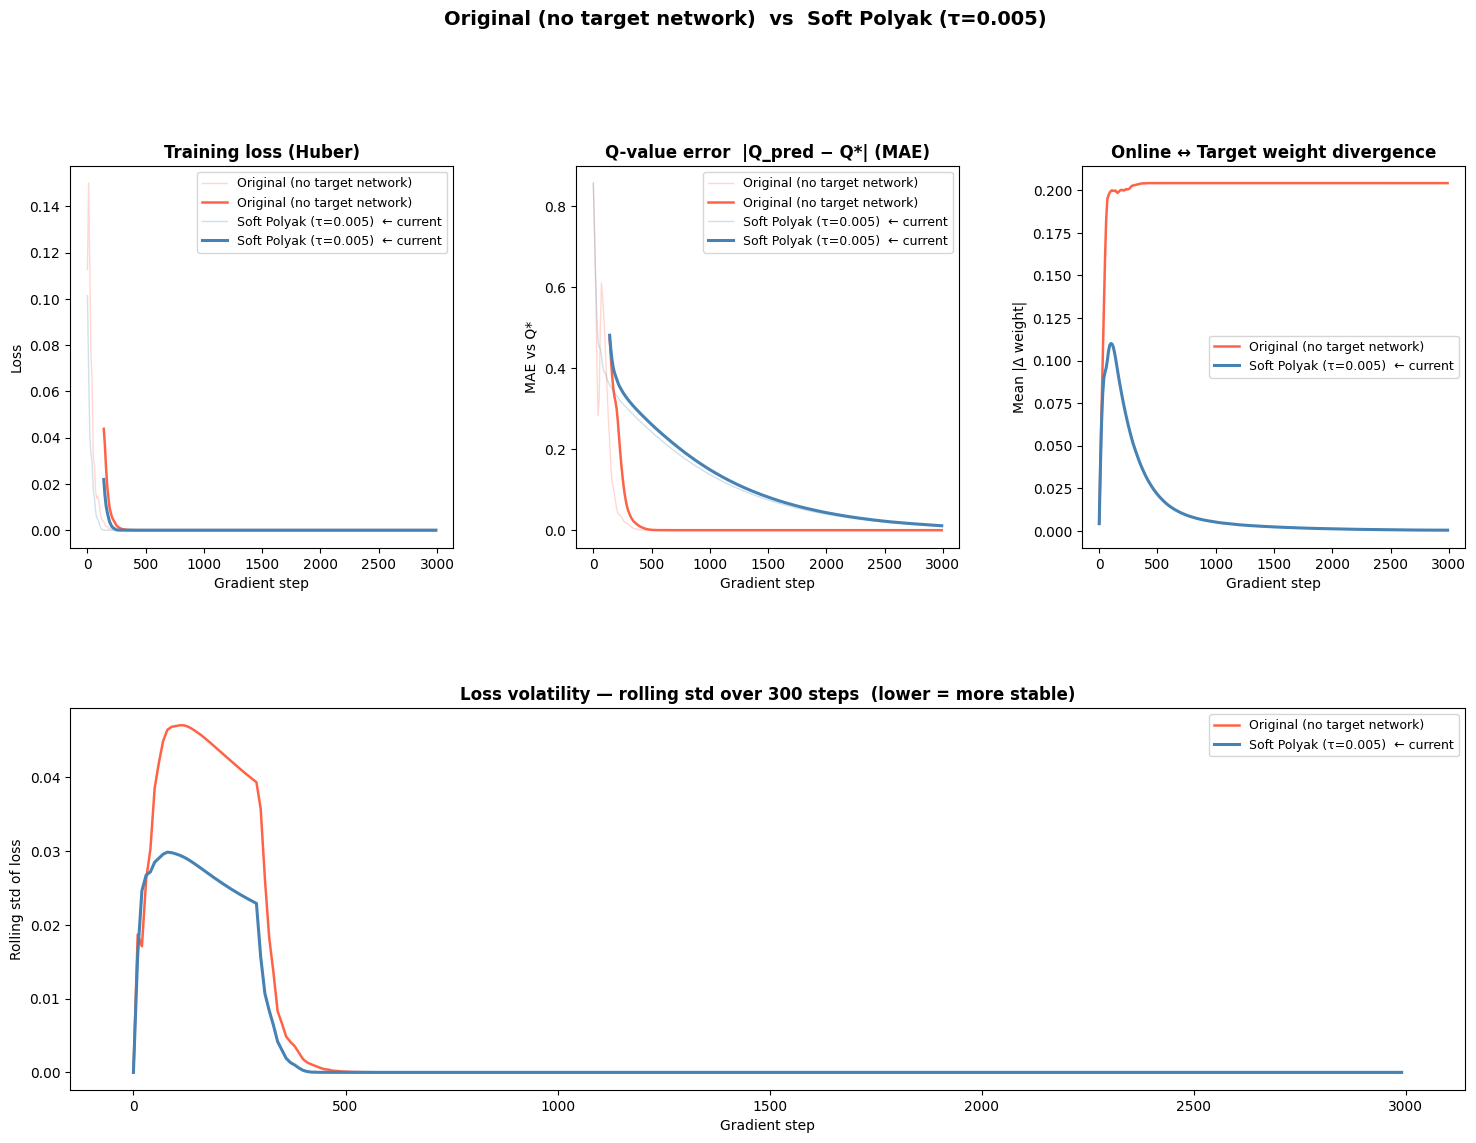

Plot saved as target_comparison.png


In [5]:
steps_logged = np.arange(len(loss_nt)) * LOG_EVERY

STYLES = {
    "no_target": dict(color="tomato",    lw=1.8, label="Original (no target network)"),
    "polyak":    dict(color="steelblue", lw=2.2, label="Soft Polyak (τ=0.005)  ← current"),
}

def smooth(x, w=15):
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

ax_loss = fig.add_subplot(gs[0, 0])
ax_err  = fig.add_subplot(gs[0, 1])
ax_div  = fig.add_subplot(gs[0, 2])

for (mode, sty), loss, err, div in zip(
    STYLES.items(),
    [loss_nt, loss_pk],
    [err_nt,  err_pk],
    [div_nt,  div_pk],
):
    ax_loss.plot(steps_logged,      loss,        alpha=0.25, **{**sty, "lw": 1})
    ax_loss.plot(steps_logged[14:], smooth(loss), **sty)

    ax_err.plot(steps_logged,      err,        alpha=0.25, **{**sty, "lw": 1})
    ax_err.plot(steps_logged[14:], smooth(err), **sty)

    ax_div.plot(steps_logged, div, **sty)

ax_loss.set_title("Training loss (Huber)", fontweight="bold")
ax_loss.set_xlabel("Gradient step"); ax_loss.set_ylabel("Loss")
ax_loss.legend(fontsize=9)

ax_err.set_title("Q-value error  |Q_pred − Q*| (MAE)", fontweight="bold")
ax_err.set_xlabel("Gradient step"); ax_err.set_ylabel("MAE vs Q*")
ax_err.legend(fontsize=9)

ax_div.set_title("Online ↔ Target weight divergence", fontweight="bold")
ax_div.set_xlabel("Gradient step"); ax_div.set_ylabel("Mean |Δ weight|")
ax_div.legend(fontsize=9)

# Row 2: loss volatility
ax_var = fig.add_subplot(gs[1, :])
W = 30
for (mode, sty), loss in zip(STYLES.items(), [loss_nt, loss_pk]):
    roll_std = [loss[max(0, i - W):i].std() for i in range(1, len(loss) + 1)]
    ax_var.plot(steps_logged, roll_std, **sty)

ax_var.set_title(
    f"Loss volatility — rolling std over {W * LOG_EVERY} steps  (lower = more stable)",
    fontweight="bold",
)
ax_var.set_xlabel("Gradient step"); ax_var.set_ylabel("Rolling std of loss")
ax_var.legend(fontsize=9)

fig.suptitle(
    "Original (no target network)  vs  Soft Polyak (τ=0.005)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.savefig("target_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved as target_comparison.png")

## 6. Target Lag Analysis

Does a slowly updated Polyak target prevent the network from learning better targets
quickly? We measure how well the *target network* tracks Q* vs the *online* network.

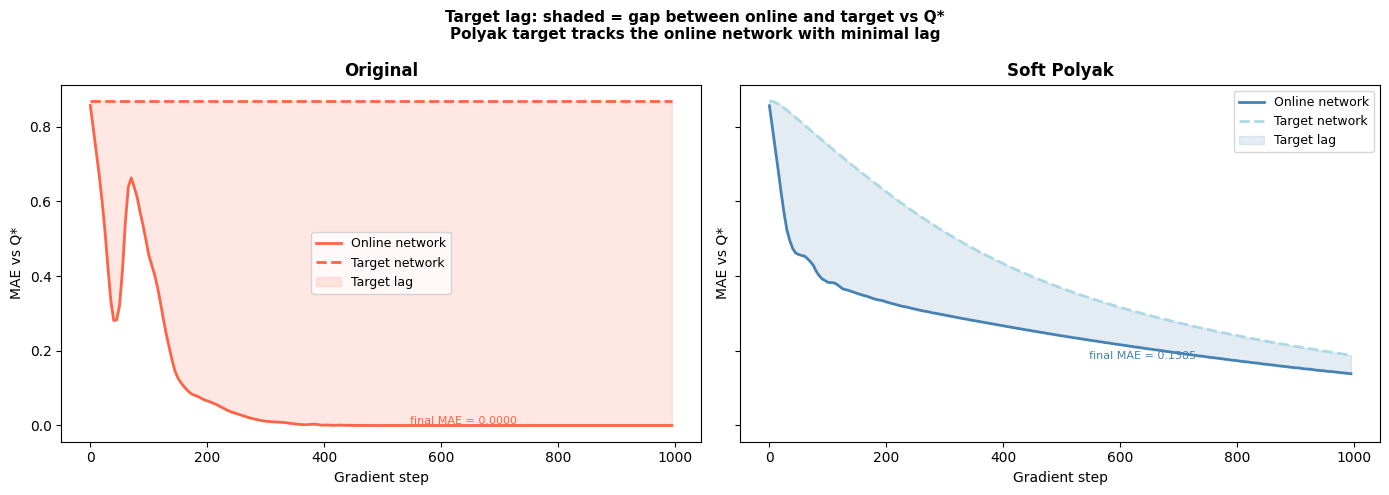

In [6]:
N_STEPS_LAG   = 1000
LOG_EVERY_LAG = 5


def run_with_target_tracking(mode):
    torch.manual_seed(99)
    online = QNet(N_STATES, N_ACTIONS).to(DEVICE)
    target = copy.deepcopy(online)
    for p in target.parameters():
        p.requires_grad = False
    optimizer = optim.Adam(online.parameters(), lr=LR)
    loss_fn = nn.HuberLoss()

    online_err, target_err = [], []

    for step in range(N_STEPS_LAG):
        s, a, r, s2 = sample_batch(BATCH)
        s_t  = one_hot(s,  N_STATES)
        s2_t = one_hot(s2, N_STATES)
        r_t  = torch.tensor(r, device=DEVICE)
        a_t  = torch.tensor(a, device=DEVICE)

        online.train()
        q_online = online(s_t)
        with torch.no_grad():
            if mode == "no_target":
                q_next = online(s2_t).max(dim=1).values
            else:
                q_next = target(s2_t).max(dim=1).values
        td_target = r_t + GAMMA * q_next
        loss = loss_fn(q_online[range(BATCH), a_t], td_target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        if mode == "polyak":
            for p_on, p_tgt in zip(online.parameters(), target.parameters()):
                p_tgt.data.mul_(1.0 - TAU).add_(TAU * p_on.data)

        if step % LOG_EVERY_LAG == 0:
            online_err.append(q_error(online))
            target_err.append(q_error(target))

    return np.array(online_err), np.array(target_err)


steps_lag = np.arange(N_STEPS_LAG // LOG_EVERY_LAG) * LOG_EVERY_LAG

online_nt, target_nt = run_with_target_tracking("no_target")
online_pk, target_pk = run_with_target_tracking("polyak")

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, mode, label, c_on, c_tgt, on_err, tgt_err in [
    (ax_l, "no_target", "Original",   "tomato",    "tomato",    online_nt, target_nt),
    (ax_r, "polyak",    "Soft Polyak", "steelblue", "lightblue", online_pk, target_pk),
]:
    ax.plot(steps_lag, on_err,  color=c_on,  lw=2.0, label="Online network")
    ax.plot(steps_lag, tgt_err, color=c_tgt, lw=2.0, linestyle="--", label="Target network")
    ax.fill_between(steps_lag, on_err, tgt_err, alpha=0.15, color=c_on, label="Target lag")
    ax.set_title(label, fontweight="bold", fontsize=12)
    ax.set_xlabel("Gradient step")
    ax.set_ylabel("MAE vs Q*")
    ax.legend(fontsize=9)
    ax.annotate(
        f"final MAE = {on_err[-1]:.4f}",
        xy=(steps_lag[-1], on_err[-1]),
        xytext=(steps_lag[-1] * 0.55, on_err[-1] * 1.25 + 0.005),
        fontsize=8, color=c_on,
    )

fig.suptitle(
    "Target lag: shaded = gap between online and target vs Q*\n"
    "Polyak target tracks the online network with minimal lag",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

## 8. Summary

| | Original (no target) | Soft Polyak τ=0.005 |
|---|---|---|
| **Target freshness** | Perfect (same net) | Near-current (EMA) |
| **Target stability** | None — shifts every step | Smooth at all times |
| **Weight divergence** | N/A | Flat, near-zero |
| **Loss volatility** | Higher | Lower |
| **Addresses concern** | — | Yes: fresh *and* stable |

**Key insight:** Polyak averaging answers the original concern directly — the target is
always almost as current as the online network (no "missing opportunities") while
moving slowly enough to keep the learning signal stable.